In [1]:
import sys
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl

warnings.filterwarnings('ignore', category=FutureWarning)

import pylimma


In [19]:
df = pd.read_csv("/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/data/processed/LIPD/plasma/LIPD_plasma_cleaned_with_metadata.csv")
uncorrected = pd.read_csv("//Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/data/raw/extracted/LIPD/plasma/neg_expression.csv")
targets = df[['SampleID',  'SubjectID', 'Batch', 'Group', 'Subgroup', 'GestAgeDelivery', "SampleGestAge"]]
#targets = df[['SampleID', 'Group', 'Subgroup', 'GestAgeDelivery']]
targets.index = targets["SampleID"]

targets_uncorrected = uncorrected[['compound']]
uncorrected.index = uncorrected["compound"]
proteome = df.drop(["SampleTimepoint", 'MetadataCanonicalID',
       'labor_onset', 'indicated_onset', 'spont_labor_flag',
       'indicated_onset_flag', 'cat_labor_onset_flag',
       'within_0_1wk_delivery_flag', 'post_birth_sample_flag'], axis=1)
proteome_uncorrected = uncorrected.drop(['compound'], axis=1)
print(proteome.head())
proteome_uncorrected.head()

    SampleID SubjectID    Group Subgroup  Batch  GestAgeDelivery  \
0  DP3-0006A  DP3-0006  Control  Control    1.0             40.0   
1  DP3-0006B  DP3-0006  Control  Control    1.0             40.0   
2  DP3-0006C  DP3-0006  Control  Control    1.0             40.0   
3  DP3-0008A  DP3-0008  Control  Control    2.0             39.0   
4  DP3-0008B  DP3-0008  Control  Control    2.0             39.0   

   SampleGestAge  LPE(16:0)_POS  PE(O_POS  PE(P_POS  ...  PC(O_NEG__42  \
0       7.428571       0.000048 -0.006230 -0.004917  ...      0.002897   
1      15.428571       0.000087  0.002930  0.005420  ...      0.003678   
2      34.285714       0.000087  0.002666  0.004720  ...      0.001369   
3       7.857143       0.000029 -0.008609 -0.010120  ...      0.003020   
4      24.857143       0.000091 -0.006439 -0.005981  ...      0.003925   

   PC(18:1_18:2)_NEG  PC(16:0_20:3)_NEG  PC(18:0_18:3)_NEG  PC(O_NEG__43  \
0           0.155934           0.164146           0.000156      0.0068

/var/folders/bj/wdn44py97n591s8mj6yf21n80000gp/T/ipykernel_48698/1484227843.py:1: DtypeWarning: Columns (0: SampleTimepoint) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/data/processed/LIPD/plasma/LIPD_plasma_cleaned_with_metadata.csv")
/var/folders/bj/wdn44py97n591s8mj6yf21n80000gp/T/ipykernel_48698/1484227843.py:2: DtypeWarning: Columns (0: c1, 1: 10, 2: 100, 3: 1006, 4: 1010, 5: 1012, 6: 1034, 7: 109, 8: 11, 9: 1104, 10: 1105, 11: 1106, 12: 1107, 13: 1108, 14: 1109, 15: 1110, 16: 1111, 17: 1112, 18: 1113, 19: 1114, 20: 1115, 21: 1116, 22: 1117, 23: 1118, 24: 1122, 25: 1123, 26: 1124, 27: 1126, 28: 1128, 29: 113, 30: 1130, 31: 1131, 32: 1132, 33: 1133, 34: 1134, 35: 1135, 36: 1136, 37: 114, 38: 1144, 39: 1145, 40: 1146, 41: 1147, 42: 1148, 43: 1150, 44: 1152, 45: 1154, 46: 1155, 47: 1156, 48: 1158, 49: 116, 50: 1161, 51: 1163, 52: 1167, 53: 1175, 54: 1179, 55: 1183, 56: 1189, 57: 119

,c1,c2,1,10,100,1005,1006,1009,101,1010,...,989,99,990,991,994,995,996,997,998,999
compound,,,,,,,,,,,,,,,,,,,,,
Pooled Control,NaN,NaN,2560.63963036259,4990.028733,502722.10381,629084.596137,29549.381274,685727.976819,13164.324188,5447.802951,...,2527.186263,630177.749203,48176.944718,4965.145743,50009.887563,8541.424418,11529.964713,13361.976289,110026.905325,11483.319681
Pooled Control,NaN,NaN,2511.44697384624,7945.157039,497679.840349,644144.890602,26718.400637,696483.707853,14127.507830,6950.421093,...,2833.648134,622090.155973,47894.766702,5336.11328,50653.623490,9758.467776,11780.885831,9969.147156,115208.472505,13732.49777
Pooled Control,NaN,NaN,2622.81939137172,6238.456442,502137.998149,680230.736245,18823.301611,701070.524354,12735.492067,1527.73074,...,4453.955449,8684.763492,49462.105685,4013.196491,52545.171540,11662.411318,11699.111156,9355.933524,113254.351499,8816.368752
Pooled Control,NaN,NaN,2895.37722783223,10170.672172,537133.989608,734330.890253,8591.166147,752740.022174,15977.760528,1399.724458,...,4573.316715,670938.175429,49933.308494,2041.229739,56057.957041,7335.128127,12878.800201,9027.317061,127833.293090,3357.969643
Pooled Control,NaN,NaN,3550.60741666212,8138.728279,573394.221929,746344.038473,7759.160192,11615.081456,16892.910263,4384.951387,...,3540.589889,713023.946713,58125.427045,1827.291372,76702.457273,6425.778559,18017.140027,7211.749445,133194.834694,2326.548918


,c1,c2,1,10,100,1005,1006,1009,101,1010,...,989,99,990,991,994,995,996,997,998,999
compound,,,,,,,,,,,,,,,,,,,,,
Pooled Control,NaN,NaN,2560.63963036259,4990.028733,502722.10381,629084.596137,29549.381274,685727.976819,13164.324188,5447.802951,...,2527.186263,630177.749203,48176.944718,4965.145743,50009.887563,8541.424418,11529.964713,13361.976289,110026.905325,11483.319681
Pooled Control,NaN,NaN,2511.44697384624,7945.157039,497679.840349,644144.890602,26718.400637,696483.707853,14127.507830,6950.421093,...,2833.648134,622090.155973,47894.766702,5336.11328,50653.623490,9758.467776,11780.885831,9969.147156,115208.472505,13732.49777
Pooled Control,NaN,NaN,2622.81939137172,6238.456442,502137.998149,680230.736245,18823.301611,701070.524354,12735.492067,1527.73074,...,4453.955449,8684.763492,49462.105685,4013.196491,52545.171540,11662.411318,11699.111156,9355.933524,113254.351499,8816.368752
Pooled Control,NaN,NaN,2895.37722783223,10170.672172,537133.989608,734330.890253,8591.166147,752740.022174,15977.760528,1399.724458,...,4573.316715,670938.175429,49933.308494,2041.229739,56057.957041,7335.128127,12878.800201,9027.317061,127833.293090,3357.969643
Pooled Control,NaN,NaN,3550.60741666212,8138.728279,573394.221929,746344.038473,7759.160192,11615.081456,16892.910263,4384.951387,...,3540.589889,713023.946713,58125.427045,1827.291372,76702.457273,6425.778559,18017.140027,7211.749445,133194.834694,2326.548918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DP3-0136E C,20629379.33177,2.416752e+07,3426.73661777895,887.052379827252,1437101.88236575,151912.972035,99.1612581208766,123334.479721,49678.987503,2541.38342843398,...,1351.59767898273,1096023.63232999,33714.6515036799,669.649323919279,167749.189268,0.35527316263248,213875.476471,1581.75044262694,62840.352016,2532.27441707944
DP3-0136E D,20645677.473233,3.494722e+07,1108.146747569,869.389129617366,718772.50813776,133565.076482,46.1358588977191,94756.023327,53439.011244,1583.91127264292,...,719.240359273179,979764.099342438,14223.281464307,446.248490288457,107462.528968,25.8737610744536,120301.230158,890.783627924152,35986.618310,1440.95575030349
DP3-0140E A,20288281.34453,3.208749e+07,1051.01065459328,1297.68361168171,556337.214605363,553019.252688,1078.17211556656,330979.238980,46437.543382,4071.11962890891,...,24684.4711678254,480208.600902295,74410.9834762855,360.897909138036,82795.217293,152.914361563102,160392.067630,2522.74125510287,191660.809584,4639.52002102165


In [20]:
X = proteome_uncorrected
var_df = pd.DataFrame(X.columns)
var_df.columns = ["uniprot_id"]
var_df.index = var_df["uniprot_id"]

obs_df = targets_uncorrected
obs_df['group'] = pd.Categorical(obs_df["Batch"], 
                                 categories = [1, 2, 3],
                                 ordered = False)

adata = ad.AnnData(X=X, obs=obs_df, var=var_df)
adata.obs_names = obs_df.index
adata.var_names = var_df.index

print(f'AnnData shape: {adata.shape}  (samples x proteins)')
print(f'\ngroup counts:\n{adata.obs.group.value_counts()}')
adata.var.head()

fig, ax = plt.subplots(figsize=(6, 5))

# PCA on samples (centre proteins, drop any all-NaN rows just in case).
Xc = adata.X - adata.X.mean(axis=0, keepdims=True)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
pcs = U * s
var_explained = (s ** 2) / (s ** 2).sum()

group_palette = {1: '#4c78a8', 2: '#e45756', 3: "#5fe456"}
for grp, colour in group_palette.items():
    m = (adata.obs['Batch'] == grp).values
    ax.scatter(pcs[m, 0], pcs[m, 1], s=80,
                color=colour, edgecolor='black', label=grp)
ax.set_xlabel(f'PC1 ({var_explained[0]:.0%})')
ax.set_ylabel(f'PC2 ({var_explained[1]:.0%})')
ax.set_title('Uncorrected PCA - Plasma Proteomics')
ax.legend(frameon=False)

fig.tight_layout()
plt.savefig("/Users/kaylaxu/Desktop/dp3_project/04_results_and_figures/batch_correction/LIPD/uncorrected_PCA_plasma.jpeg")


KeyError: 'Batch'

In [37]:
proteome.index = targets.index

In [38]:
proteome

,A1BG,AAMDC,AARSD1,ABCA2,ABHD14B,ABL1,ABO,ABRAXAS2,ACAA1,ACADM,...,ZCCHC8,ZFYVE19,ZHX2,ZNF75D,ZNF830,ZNRD2,ZNRF4,ZP3,ZP4,ZPR1
SampleID,,,,,,,,,,,,,,,,,,,,,
DP3-0005 A,-0.118800,0.010800,-0.969100,0.612200,-0.323100,-0.438300,0.997500,-1.085200,-3.607000,-0.961800,...,-0.049700,-1.135300,-0.066700,-1.900600,0.182300,-1.309200,-0.341700,-4.710900,-0.394100,1.984200
DP3-0005 B,0.205100,0.114600,-0.890000,-0.682700,-0.248300,-0.144700,0.988500,-0.759800,-1.562800,0.041700,...,-0.441200,-0.633500,0.127900,0.028500,0.122400,-0.642800,-0.035000,-4.249900,-1.186200,1.010700
DP3-0005 C,0.294500,0.215700,-0.985700,0.152800,0.234900,0.251300,1.000500,-0.667900,0.191400,-0.016100,...,0.426100,-0.785400,0.261500,0.065000,0.017400,-0.719900,0.058300,-3.261500,0.190500,0.702600
DP3-0005 D,0.220500,0.602300,1.166300,0.569700,0.908100,0.568600,1.270800,0.893200,-0.816300,-0.433300,...,1.021000,1.067200,-0.000700,-0.330500,0.122800,-0.116400,0.483400,-3.174700,1.543600,1.438300
DP3-0006 A,-0.845500,-0.282800,-0.073500,-1.159700,-0.101100,-0.526900,1.064900,-0.918800,-0.279100,-0.094600,...,-0.737600,-0.026200,-0.146300,5.360100,0.217900,-0.029200,-0.286200,-3.291600,0.031400,-1.265700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DP3-0423EC,-0.148684,1.158201,1.566625,-0.660102,1.490379,2.025664,0.113782,1.410881,1.430113,1.856517,...,-0.013514,3.405962,0.462841,1.051547,0.258313,1.907873,-0.074674,-0.984755,1.053756,-0.017010
DP3-0423ED,0.147157,0.998953,0.942248,0.212259,1.399016,1.640309,-0.195875,1.292275,0.873440,1.982414,...,-0.022900,2.622223,0.039352,1.819592,0.270371,1.926702,-0.661463,0.050741,1.674299,-0.123878
DP3-0423EE,0.132737,0.372392,0.284162,-0.509455,0.886458,1.018788,-0.333525,0.442570,1.158543,1.300998,...,0.041597,1.934383,0.191117,1.515041,0.331592,1.497776,-0.301695,-0.218085,1.228547,-0.539182


In [39]:
by = "Batch"
X = proteome
var_df = pd.DataFrame(X.columns)
var_df.columns = ["uniprot_id"]
var_df.index = var_df["uniprot_id"]


obs_df = targets
#unique_subgroups = obs_df[by].unique()


adata = ad.AnnData(X=X, obs=obs_df, var=var_df)
adata.obs_names = obs_df.index
adata.var_names = var_df.index
'''
print(f'AnnData shape: {adata.shape}  (samples x proteins)')
#print(f'\ngroup counts:\n{adata.obs.group.value_counts()}')
adata.var.head()

fig, ax = plt.subplots(figsize=(6, 5))

# PCA on samples (centre proteins, drop any all-NaN rows just in case).
Xc = adata.X - adata.X.mean(axis=0, keepdims=True)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
pcs = U * s
var_explained = (s ** 2) / (s ** 2).sum()

# --- Dynamically generate the group palette ---
num_groups = len(unique_subgroups)
# 'tab20' provides 20 distinct categorical colors. If you have more than 20 subgroups, 
# it falls back to spacing them out along the 'rainbow' continuous colormap.
if num_groups <= 20:
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i) for i in range(num_groups)]
else:
    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0, 1, num_groups))

group_palette = dict(zip(unique_subgroups, colors))
# ----------------------------------------------

for grp, colour in group_palette.items():
    m = (adata.obs[by] == grp).values
    ax.scatter(pcs[m, 0], pcs[m, 1], s=80,
                color=colour, edgecolor='black', label=grp)

ax.set_xlabel(f'PC1 ({var_explained[0]:.0%})')
ax.set_ylabel(f'PC2 ({var_explained[1]:.0%})')
ax.set_title('Batch Corrected PCA - Plasma Proteomics')

# Move legend outside the plot area in case there are many groups
ax.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

fig.tight_layout()
plt.savefig("/Users/kaylaxu/Desktop/dp3_project/04_results_and_figures/batch_correction/PROT/corrected_PCA_plasma.jpeg")
'''

'\nprint(f\'AnnData shape: {adata.shape}  (samples x proteins)\')\n#print(f\'\ngroup counts:\n{adata.obs.group.value_counts()}\')\nadata.var.head()\n\nfig, ax = plt.subplots(figsize=(6, 5))\n\n# PCA on samples (centre proteins, drop any all-NaN rows just in case).\nXc = adata.X - adata.X.mean(axis=0, keepdims=True)\nU, s, Vt = np.linalg.svd(Xc, full_matrices=False)\npcs = U * s\nvar_explained = (s ** 2) / (s ** 2).sum()\n\n# --- Dynamically generate the group palette ---\nnum_groups = len(unique_subgroups)\n# \'tab20\' provides 20 distinct categorical colors. If you have more than 20 subgroups, \n# it falls back to spacing them out along the \'rainbow\' continuous colormap.\nif num_groups <= 20:\n    cmap = plt.get_cmap(\'tab20\')\n    colors = [cmap(i) for i in range(num_groups)]\nelse:\n    cmap = plt.get_cmap(\'rainbow\')\n    colors = cmap(np.linspace(0, 1, num_groups))\n\ngroup_palette = dict(zip(unique_subgroups, colors))\n# ----------------------------------------------\n\nfor g

In [40]:
'''
from sklearn.cluster import KMeans

# 1. Cluster the samples based on their first 2 Principal Components
# We use n_clusters=2 since you observed two distinct clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pcs[:, :2]) # pcs[:, 0] is PC1, pcs[:, 1] is PC2

# 2. Add the cluster labels to your observation dataframe
adata.obs['pca_cluster'] = cluster_labels
obs_df['pca_cluster'] = cluster_labels

# 3. Extract the metadata (rows) for each cluster
cluster_0_metadata = obs_df[obs_df['pca_cluster'] == 0]
cluster_1_metadata = obs_df[obs_df['pca_cluster'] == 1]

# 4. Extract the proteome expression data (rows) for each cluster
cluster_0_proteome = proteome.loc[cluster_0_metadata.index]
cluster_1_proteome = proteome.loc[cluster_1_metadata.index]

print(f"Cluster 0 size: {len(cluster_0_metadata)} samples")
print(f"Cluster 1 size: {len(cluster_1_metadata)} samples")

# Optional: Print the subgroup breakdown of each cluster to see what's driving the split
print("\nCluster 0 Subgroup makeup:")
print(cluster_0_metadata['Subgroup'].value_counts())

print("\nCluster 1 Subgroup makeup:")
print(cluster_1_metadata['Subgroup'].value_counts())

cluster_0_metadata.to_csv("/Users/kaylaxu/Desktop/dp3_project/data/processed/PROT/cluster0_meta.csv")
cluster_0_proteome.to_csv("/Users/kaylaxu/Desktop/dp3_project/data/processed/PROT/cluster0_expr.csv")
cluster_1_metadata.to_csv("/Users/kaylaxu/Desktop/dp3_project/data/processed/PROT/cluster1_meta.csv")
cluster_1_proteome.to_csv("/Users/kaylaxu/Desktop/dp3_project/data/processed/PROT/cluster1_expr.csv")
'''

'\nfrom sklearn.cluster import KMeans\n\n# 1. Cluster the samples based on their first 2 Principal Components\n# We use n_clusters=2 since you observed two distinct clusters\nkmeans = KMeans(n_clusters=2, random_state=42, n_init=10)\ncluster_labels = kmeans.fit_predict(pcs[:, :2]) # pcs[:, 0] is PC1, pcs[:, 1] is PC2\n\n# 2. Add the cluster labels to your observation dataframe\nadata.obs[\'pca_cluster\'] = cluster_labels\nobs_df[\'pca_cluster\'] = cluster_labels\n\n# 3. Extract the metadata (rows) for each cluster\ncluster_0_metadata = obs_df[obs_df[\'pca_cluster\'] == 0]\ncluster_1_metadata = obs_df[obs_df[\'pca_cluster\'] == 1]\n\n# 4. Extract the proteome expression data (rows) for each cluster\ncluster_0_proteome = proteome.loc[cluster_0_metadata.index]\ncluster_1_proteome = proteome.loc[cluster_1_metadata.index]\n\nprint(f"Cluster 0 size: {len(cluster_0_metadata)} samples")\nprint(f"Cluster 1 size: {len(cluster_1_metadata)} samples")\n\n# Optional: Print the subgroup breakdown of 

design matrix:
            Intercept  HDP
SampleID                  
DP3-0005 A        1.0  0.0
DP3-0005 B        1.0  0.0
DP3-0005 C        1.0  0.0
DP3-0005 D        1.0  0.0
DP3-0006 A        1.0  0.0
DP3-0006 B        1.0  0.0
DP3-0006 C        1.0  0.0
DP3-0006 D        1.0  0.0
DP3-0008A         1.0  0.0
DP3-0008B         1.0  0.0

contrast:
           CompvsCtrl
Intercept         0.0
HDP               1.0
keys stored in adata.uns["pylimma"]:
['Amean', 'F', 'F_p_value', 'coef_names', 'coefficients', 'contrast_names', 'contrasts', 'cov_coefficients', 'design', 'df_prior', 'df_residual', 'df_total', 'genes', 'lods', 'method', 'p_value', 'pivot', 'proportion', 'rank', 's2_post', 's2_prior', 'sigma', 'stdev_unscaled', 't', 'targets', 'var_prior']
differentially abundant proteins at adj_p_value < 0.05: 919
differentially abundant proteins at adj_p_value < 0.01: 669


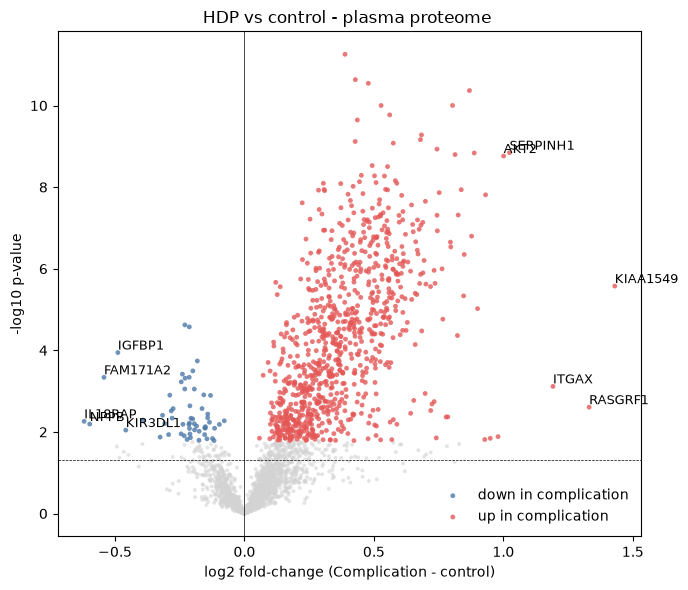

In [44]:
# comps = ["HDP", "FGR", "sPTB", "PE"]
comps= ["HDP"]
tissue = "plasma"

for complication in comps:
    if complication == "PE":
        group = adata.obs["Subgroup"]
        design = pd.DataFrame({
            'Intercept':     1.0,
            complication: group.str.contains("PE|HELLP", regex=True, na=False).astype(float).values,
            }, index=adata.obs_names)
    else:
        group  = adata.obs['Group']
        design = pd.DataFrame({
            'Intercept':     1.0,
            complication: (group == complication).astype(float).values,
            }, index=adata.obs_names)


    
    contrasts = pylimma.make_contrasts(CompvsCtrl=complication, levels=design)

    print('design matrix:')
    print(design.head(10))
    print('\ncontrast:')
    print(contrasts)

    pylimma.lm_fit(adata, design)
    pylimma.contrasts_fit(adata, contrasts=contrasts)
    pylimma.e_bayes(adata)

    print('keys stored in adata.uns["pylimma"]:')
    print(sorted(adata.uns['pylimma'].keys()))

    top = pylimma.top_table(adata, coef='CompvsCtrl',
                            number=np.inf, sort_by='p')


    top = top.join(adata.var[['uniprot_id']], how='left')

    n_sig_05 = int((top['adj_p_value'] < 0.05).sum())
    n_sig_01 = int((top['adj_p_value'] < 0.01).sum())
    print(f'differentially abundant proteins at adj_p_value < 0.05: {n_sig_05:,}')
    print(f'differentially abundant proteins at adj_p_value < 0.01: {n_sig_01:,}')

    display_cols = ['uniprot_id', 'log_fc', 'ave_expr', 't',
                    'p_value', 'adj_p_value', 'b']
    top.loc[:, display_cols].head(15).round(3)

    fig, ax = plt.subplots(figsize=(7, 6))

    sig_up   = (top['adj_p_value'] < 0.05) & (top['log_fc'] > 0)
    sig_down = (top['adj_p_value'] < 0.05) & (top['log_fc'] < 0)
    ns       = ~(sig_up | sig_down)

    nlp = -np.log10(np.maximum(top['p_value'].values, 1e-300))

    ax.scatter(top.loc[ns, 'log_fc'],   nlp[ns.values],
            s=8, color='lightgrey', alpha=0.6, edgecolor='none')
    ax.scatter(top.loc[sig_down, 'log_fc'], nlp[sig_down.values],
            s=12, color='#4c78a8', alpha=0.8,
            edgecolor='none', label= 'down in complication')
    ax.scatter(top.loc[sig_up, 'log_fc'],   nlp[sig_up.values],
            s=12, color='#e45756', alpha=0.8,
            edgecolor='none', label='up in complication')


    sig = top[top['adj_p_value'] < 0.05].copy()
    top_up   = sig.sort_values('log_fc', ascending=False).head(5)
    top_down = sig.sort_values('log_fc', ascending=True ).head(5)
    for _, row in pd.concat([top_up, top_down]).iterrows():
        label = row['uniprot_id']
        if not isinstance(label, str) or ';' in label or label == '':
            continue
        ax.annotate(label, (row['log_fc'], -np.log10(max(row['p_value'], 1e-300))),
                    fontsize=9, ha='left', va='bottom')

    ax.axhline(-np.log10(0.05), color='black', lw=0.5, linestyle='--')
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel('log2 fold-change (Complication - control)')
    ax.set_ylabel('-log10 p-value')
    ax.set_title(f'{complication} vs control - plasma proteome ')
    ax.legend(frameon=False, loc='lower right')
    fig.tight_layout()
    plt.savefig(f"/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/04_results_and_figures/differential_expression/limma_plots/test/PROT_{complication}_v_control_{tissue}.jpeg")

In [ ]:
targets.groupby(["Batch"])["Group"].value_counts()

Batch  Group  
1      Control    64
       HDP        39
       sPTB       14
       FGR        11
2      Control    80
       HDP        43
       FGR        24
       sPTB        7
3      Control    91
       HDP        79
       FGR        52
       sPTB       26
Name: count, dtype: int64

In [ ]:
targets

,SampleID,SubjectID,SampleGestAge,Batch,Group,Subgroup,GestAgeDelivery,pca_cluster
SubjectID,,,,,,,,
DP3-0005,DP3-0005 A,DP3-0005,11.857143,1,FGR,FGR <5,36.857143,1
DP3-0005,DP3-0005 B,DP3-0005,19.571429,1,FGR,FGR <5,36.857143,1
DP3-0005,DP3-0005 C,DP3-0005,28.857143,1,FGR,FGR <5,36.857143,1
DP3-0005,DP3-0005 D,DP3-0005,36.714286,1,FGR,FGR <5,36.857143,1
DP3-0006,DP3-0006 A,DP3-0006,7.428571,1,Control,Control,40.000000,1
...,...,...,...,...,...,...,...,...
DP3-0423,DP3-0423EC,DP3-0423,29.000000,3,HDP,LO mild SIPE,38.142857,1
DP3-0423,DP3-0423ED,DP3-0423,37.000000,3,HDP,LO mild SIPE,38.142857,1
DP3-0423,DP3-0423EE,DP3-0423,38.857143,3,HDP,LO mild SIPE,38.142857,1


In [ ]:
adata.X

array([['DP3-0005', 1, 11.857142857142858, ..., -4.7109, -0.3941, 1.9842],
       ['DP3-0005', 1, 19.571428571428573, ..., -4.2499, -1.1862, 1.0107],
       ['DP3-0005', 1, 28.857142857142858, ..., -3.2615, 0.1905, 0.7026],
       ...,
       ['DP3-0423', 3, 38.85714286, ..., -0.2180853185881131,
        1.228547499965802, -0.5391818000355104],
       ['DP3-0436', 3, 13.71428571, ..., -3.2099497361394445,
        -0.2544394327582648, -0.0721705928268937],
       ['DP3-0436', 3, 23.0, ..., -2.436302146634984,
        -1.1445166978367367, -1.11893175708044]],
      shape=(530, 2818), dtype=object)

In [6]:
uncorrected = pd.read_csv("/Users/kaylaxu/Desktop/PiekosLab/kaylaxu/dp3_project/data/raw/extracted/PROT/plasma/uncorrected_plasma_expr.csv")

In [7]:
uncorrected.shape

(530, 2822)

In [8]:
uncorrected

,SampleID,SubjectID,Batch,Group,Subgroup,GestAgeDelivery,SampleGestAge,A1BG,AAMDC,AARSD1,...,ZCCHC8,ZFYVE19,ZHX2,ZNF75D,ZNF830,ZNRD2,ZNRF4,ZP3,ZP4,ZPR1
0,DP3-0005 A,DP3-0005,1,FGR,FGR <5,36.857143,11.857143,-0.1188,0.0108,-0.9691,...,-0.0497,-1.1353,-0.0667,-1.9006,0.1823,-1.3092,-0.3417,-4.7109,-0.3941,1.9842
1,DP3-0005 B,DP3-0005,1,FGR,FGR <5,36.857143,19.571429,0.2051,0.1146,-0.8900,...,-0.4412,-0.6335,0.1279,0.0285,0.1224,-0.6428,-0.0350,-4.2499,-1.1862,1.0107
2,DP3-0005 C,DP3-0005,1,FGR,FGR <5,36.857143,28.857143,0.2945,0.2157,-0.9857,...,0.4261,-0.7854,0.2615,0.0650,0.0174,-0.7199,0.0583,-3.2615,0.1905,0.7026
3,DP3-0005 D,DP3-0005,1,FGR,FGR <5,36.857143,36.714286,0.2205,0.6023,1.1663,...,1.0210,1.0672,-0.0007,-0.3305,0.1228,-0.1164,0.4834,-3.1747,1.5436,1.4383
4,DP3-0006 A,DP3-0006,1,Control,Control,40.000000,7.428571,-0.8455,-0.2828,-0.0735,...,-0.7376,-0.0262,-0.1463,5.3601,0.2179,-0.0292,-0.2862,-3.2916,0.0314,-1.2657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,DP3-0423EC,DP3-0423,3,HDP,LO mild SIPE,38.142857,29.000000,-0.1257,1.3772,1.7848,...,-0.0721,3.7688,0.3550,0.8165,0.7465,1.6708,-0.1430,-0.7013,0.8440,-0.0251
526,DP3-0423ED,DP3-0423,3,HDP,LO mild SIPE,38.142857,37.000000,0.1287,1.1788,1.0217,...,-0.0877,2.8919,-0.0005,1.5998,0.7840,1.6885,-1.0536,0.2039,1.4099,-0.1489
527,DP3-0423EE,DP3-0423,3,HDP,LO mild SIPE,38.142857,38.857143,0.1163,0.3982,0.2174,...,0.0195,2.1223,0.1269,1.2892,0.9744,1.2853,-0.4953,-0.0311,1.0034,-0.6300
528,DP3-0436A,DP3-0436,3,sPTB,sptb+gHTN,29.428571,13.714286,-0.2432,-0.3628,-0.9211,...,-1.2699,0.4339,-0.2233,-0.4335,-0.6410,1.1107,-0.1235,-2.6465,-0.3490,-0.0890
